# &laquo;Машинное обучение&raquo;, AI Masters

### Домашняя работа №2. Pandas, Matplotlib, Seaborn.

In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [280]:
plt.rcParams['font.family'] = 'sans-serif'

## Блок 1. Воспроизведение графиков (6 баллов)

Дополнительные баллы можно получить при очень точном воспроизведении графиков.

Disclaimer: Не все графики в этом блоке имеют глубокий смысл. Скорее они призваны дать вам увидеть "а как еще можно". Надеюсь, что процесс их воспроизведения будет для вас полезен ;)

### Задача 1.0 (0 баллов)

Загрузите датасет в Pandas.

На основе этого датасета вам необходимо будет построить графики в заданиях блока 1.

In [281]:
!wget https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/winemag-data-130k-noreview-v2.csv -O winemag-data-noreview.csv

--2025-10-02 19:39:42--  https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/winemag-data-130k-noreview-v2.csv
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18477761 (18M) [text/csv]
Saving to: ‘winemag-data-noreview.csv’

winemag-data-norevi 100%[===================>]  17.62M  9.45MB/s    in 1.9s    

2025-10-02 19:39:44 (9.45 MB/s) - ‘winemag-data-noreview.csv’ saved [18477761/18477761]



In [282]:
df = pd.read_csv('winemag-data-noreview.csv')
df.head()

,country,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [283]:
df.shape

(119900, 12)

In [284]:
df.describe()

,points,price
count,119900.000000,111508.000000
mean,88.442168,35.621525
std,3.093367,42.110553
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


### Задача 1.1 (0.5 балла)

Напишите код, который воспроизводит график:

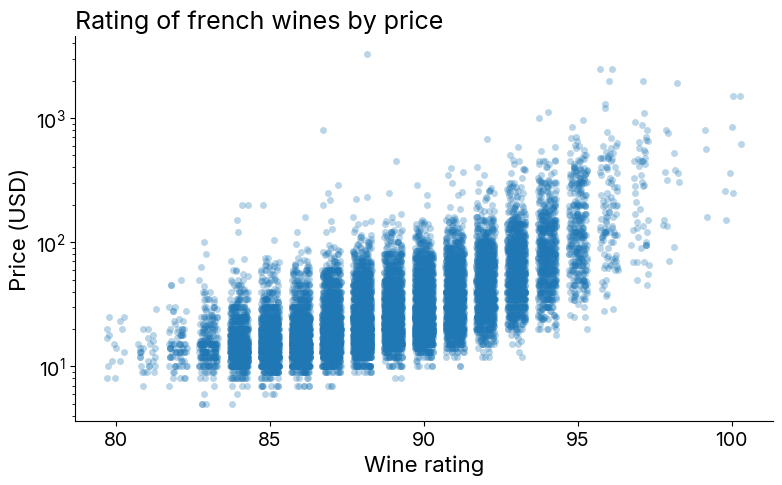

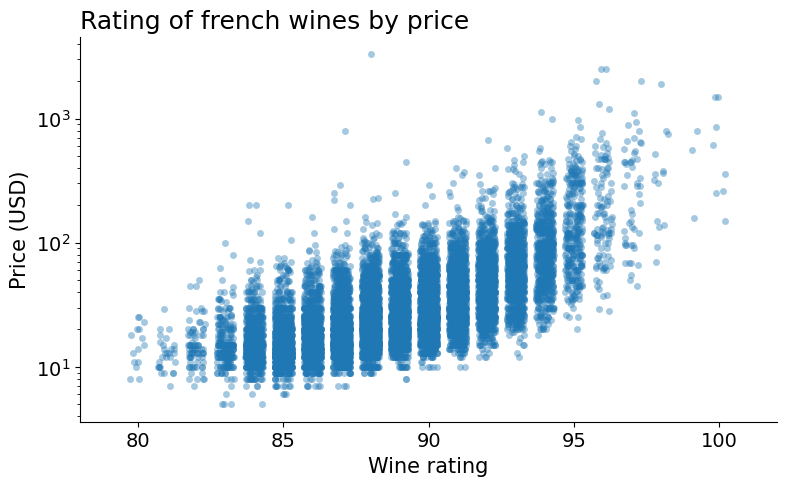

In [285]:

plt.figure(figsize=(9, 5))
sns.stripplot(df[df['country'] == 'France'], x = 'points', y = 'price', alpha = 0.4, jitter = 0.3)
plt.yscale('log')
plt.xlabel('Wine rating', size = 15)
plt.ylabel('Price (USD)', size = 15)
plt.xticks(ticks = np.arange(0, 25, 5), labels = np.arange(80, 105, 5), size = 14)
plt.xlim(-2, 22)
plt.title('Rating of french wines by price', size = 18, loc = 'left')
sns.despine()
plt.show()


### Задача 1.2 (0.5 балла)

Напишите код, который воспроизводит график:

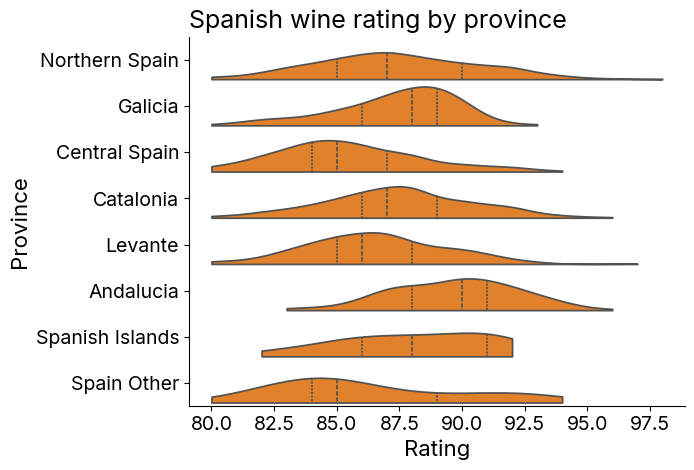

Text(0.0, 1.0, 'Spanish wine rating by province')

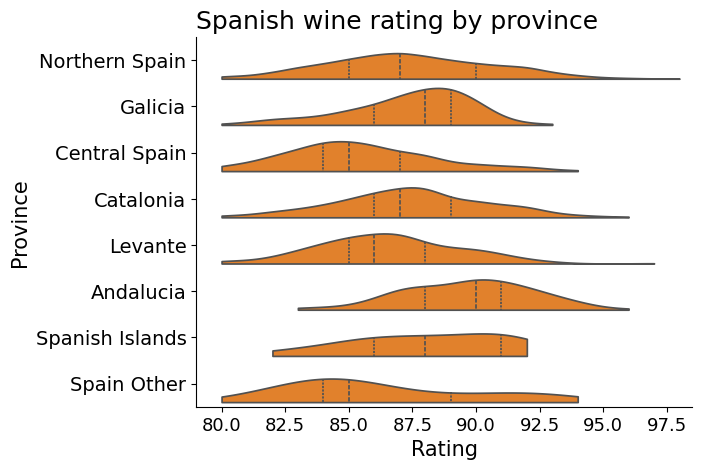

In [286]:
sns.violinplot(df[df['country']=='Spain'], y = 'province', x = 'points', split=True, inner="quart", orient = 'h', color=sns.color_palette()[1], cut=0)
sns.despine()
plt.rc('ytick', labelsize=14)
plt.xlabel('Rating', size = 15)
plt.ylabel('Province', size = 15)
plt.xlim(79, 98.5)
plt.xticks(ticks = np.arange(80, 98, 2.5), size = 13)
plt.title('Spanish wine rating by province', size = 18, loc = 'left')

### Задача 1.3 (1 балл)

Напишите код, который воспроизводит график:

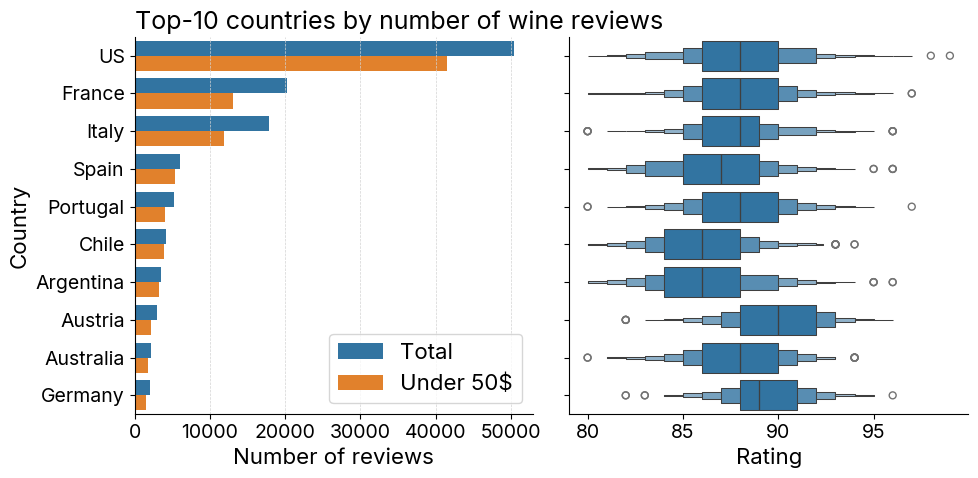

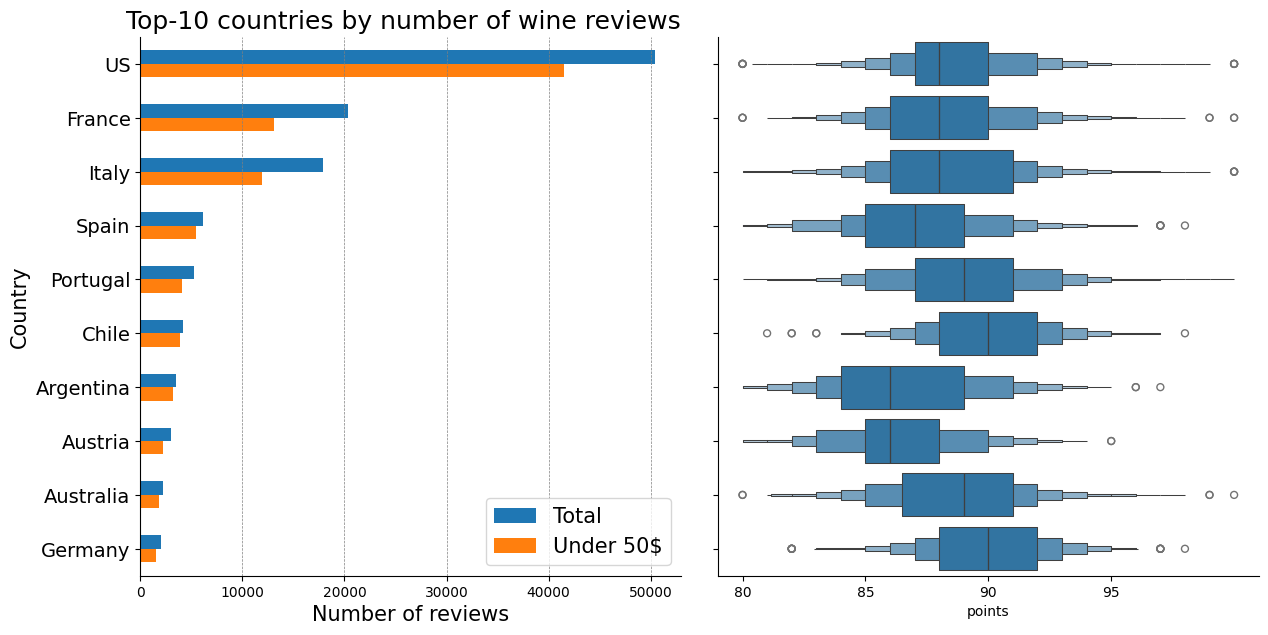

In [287]:
f, (ax1, ax2) = plt.subplots(1,2, sharey=True, figsize = (12,6))
f.tight_layout()
sns.despine()
plt.rc('ytick', labelsize=14)

# barplot
top10 = df.country.value_counts()[:10].to_frame()
top10['under'] = df[df['price'] <= 50].country.value_counts()[:10].values
top10.columns = ['Total', 'Under 50$']
top10.plot.barh(ax = ax1)
ax1.set_ylabel('Country', size = 15)
ax1.set_xlabel('Number of reviews', size = 15)
ax1.legend(prop={'size':15})
ax1.grid(axis = 'x', color='gray', linestyle='dashed', linewidth=0.5)
ax1.set_title('Top-10 countries by number of wine reviews', size = 18, loc = 'right')

# boxenplot
top10 = df[df['country'].isin(top10.index)]
sns.boxenplot(data=top10, y='country', x='points', ax=ax2, orient = 'h')
ax2.set_xticks(ticks = np.arange(80, 98, 5))
plt.show()

### Задача 1.4 (1.5 балла)

Напишите код, который воспроизводит график:

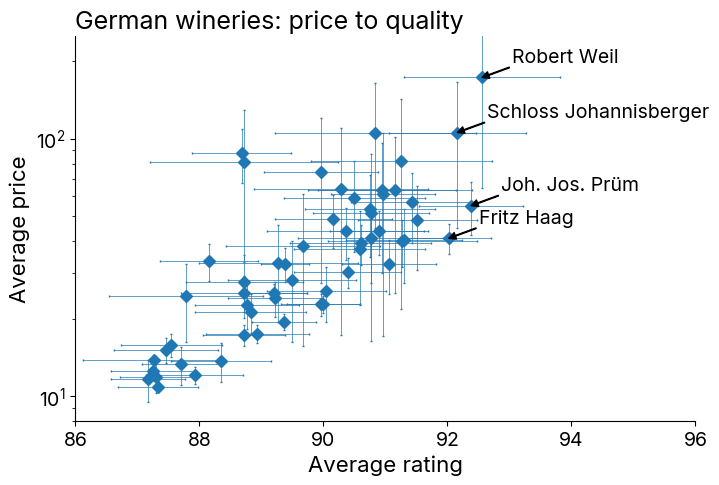

**Указание**: точки - средние, "усы" - стандартные отклонения. Взяты только винодельни с 10 или более отзывами в датасете.

In [288]:
good_cntrs = df[df['country'] == 'Germany']['winery'].value_counts().to_frame()
good_cntrs = good_cntrs[good_cntrs['count'] >= 10].index
data = df[df['winery'].isin(good_cntrs)].groupby('winery')[['points', 'price']].describe()

In [289]:
'Robert Weil' in data.index

True

In [290]:
text_labels = data.sort_values([('points', 'mean')], ascending=False).head(4)[[('points', 'mean'), ('price', 'mean')]]
text_labels

,points,price
,mean,mean
winery,,
Robert Weil,92.559322,172.915254
Joh. Jos. Prüm,92.382353,54.967742
Schloss Johannisberger,92.160000,105.695652
Fritz Haag,92.023256,41.073171


Text(0.0, 1.0, 'German wineries: price to quality')

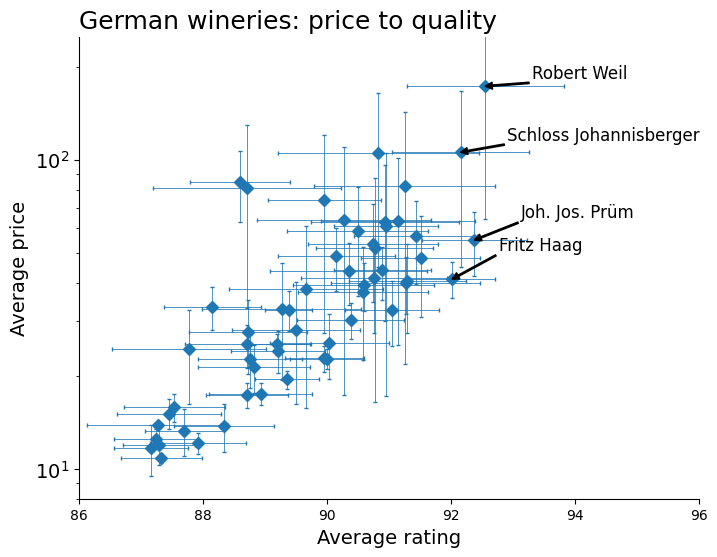

In [291]:
plt.figure(figsize = (8,6))
plt.errorbar(data[('points', 'mean')], data[('price', 'mean')], xerr = data[('points', 'std')]/2, yerr = data[('price', 'std')]/2, fmt='D', elinewidth = 0.55, capsize = 1.5)
sns.despine()
plt.xlim(86, 96)
plt.ylim(8, 250)
plt.yscale('log')
for name, coords in text_labels.iterrows():
    plt.annotate(name, coords, arrowprops = {'width' : 1, 'headwidth' : 5, 'headlength' : 5, 'color' : 'black'}, xytext = coords + np.array([0.75, 10]), size = 12)
plt.xlabel('Average rating', size = 14)
plt.ylabel('Average price', size = 14)
plt.title('German wineries: price to quality', loc = 'left', size = 18)

### Задача 1.5 (1.5 балла)

Напишите код, который воспроизводит график:

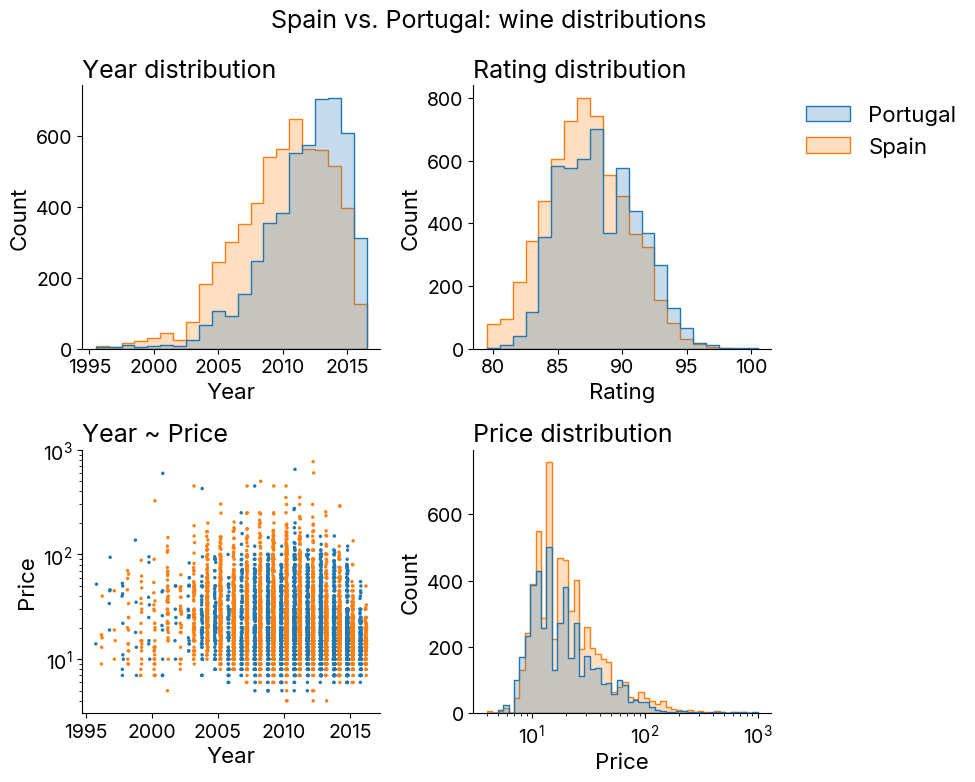

**Указание**: год получен по данным датасета с помощью средств Pandas. Годы вне диапазона [1996, 2016] считаются неизвестными.

In [292]:
df_15 = df[df['country'].isin(['Spain', 'Portugal'])]
df_15['year'] = df_15['title'].str.extract(r'(\b\d{4}\b)')
df_15 = df_15[-df_15['year'].isna()]
df_15['year'] = [int(x) for x in df_15['year']]
df_15 = df_15[(df_15['year'] >= 1996) & (df_15['year'] <= 2016)]

/tmp/ipython-input-2478360716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_15['year'] = df_15['title'].str.extract(r'(\b\d{4}\b)')


In [293]:
df_15.columns

Index(['country', 'designation', 'points', 'price', 'province', 'region_1',
       'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety',
       'winery', 'year'],
      dtype='object')

/tmp/ipython-input-1677129367.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(fontsize=15)


Text(0, 0.5, 'count')

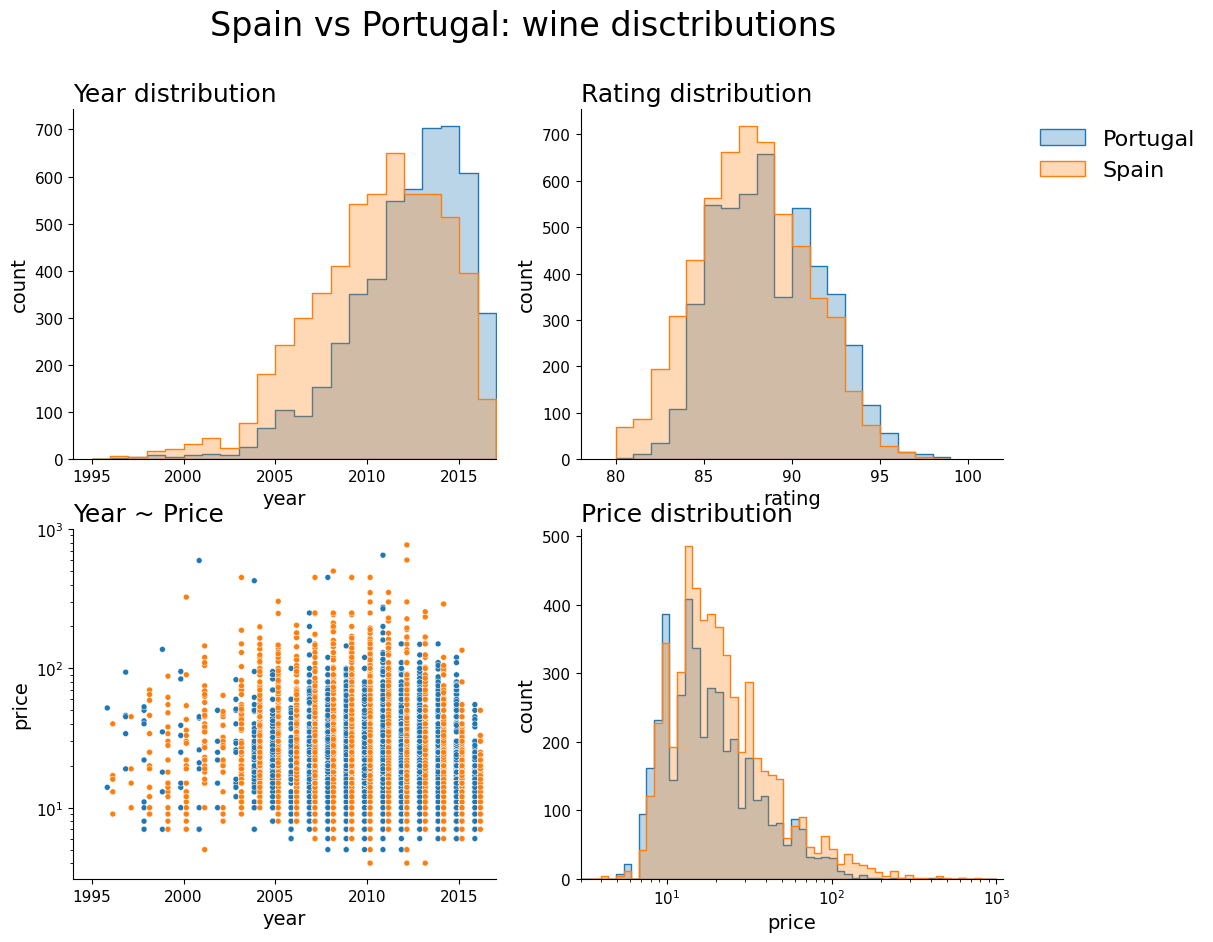

In [294]:
f, axes = plt.subplots(2, 2, figsize = (12, 10))
f.suptitle('Spain vs Portugal: wine disctributions', size = 24)


sns.histplot(df_15[df_15.country == 'Portugal'].year, bins=np.arange(1995, 2018, 1), alpha=0.3, ax = axes[0,0], element="step")
sns.histplot(df_15[df_15.country == 'Spain'].year, bins=np.arange(1995, 2018, 1), alpha=0.3, ax = axes[0,0], element="step")
sns.despine()
axes[0, 0].set_xlim(1994, 2017)
axes[0, 0].set_title('Year distribution', fontsize=18, loc = 'left')
axes[0, 0].tick_params(axis='both', labelsize=11)
axes[0, 0].legend(fontsize=15)
axes[0, 0].get_legend().remove()
axes[0, 0].set_xlabel('year', size = 14)
axes[0, 0].set_ylabel('count', size = 14)



sns.histplot(df_15[df_15.country == 'Portugal'].points, bins=np.arange(80, 100, 1), alpha=0.3, ax = axes[0,1], element="step", label = 'Portugal')
sns.histplot(df_15[df_15.country == 'Spain'].points, bins=np.arange(80, 100, 1), alpha=0.3, ax = axes[0,1], element="step", label = 'Spain')
sns.despine()
axes[0, 1].set_xlim(78, 102)
axes[0, 1].set_title('Rating distribution', fontsize=18, loc = 'left')
axes[0, 1].legend(loc='upper left', bbox_to_anchor=(1.04, 1), fontsize = 16, frameon = False)
axes[0, 1].tick_params(axis='both', labelsize=11)
axes[0, 1].set_xlabel('rating', size = 14)
axes[0, 1].set_ylabel('count', size = 14)



sns.scatterplot(x = df_15[df_15.country == 'Portugal'].year - 0.15, y = df_15[df_15.country == 'Portugal'].price, ax = axes[1,0], size = 0.5)
sns.scatterplot(x = df_15[df_15.country == 'Spain'].year + 0.15, y = df_15[df_15.country == 'Spain'].price, ax = axes[1,0], size = 0.5)
sns.despine()
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlim(1994, 2017)
axes[1, 0].set_title('Year ~ Price', fontsize=18, loc = 'left')
axes[1, 0].legend(fontsize=15)
axes[1, 0].tick_params(axis='both', labelsize=11)
axes[1, 0].get_legend().remove()
axes[1, 0].set_xlabel('year', size = 14)
axes[1, 0].set_ylabel('price', size = 14)



sns.histplot(df_15[df_15.country == 'Portugal'].price, bins=np.logspace(0, 3, 66), alpha=0.3, ax = axes[1,1], element="step", label = 'Portugal')
sns.histplot(df_15[df_15.country == 'Spain'].price, bins=np.logspace(0, 3, 66), alpha=0.3, ax = axes[1,1], element="step", label = 'Spain')
sns.despine()
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlim(3, 1100)
axes[1, 1].set_title('Price distribution', fontsize=18, loc = 'left')
axes[1, 1].legend(fontsize=15)
axes[1, 1].tick_params(axis='both', labelsize=11)
axes[1, 1].get_legend().remove()
axes[1, 1].set_xlabel('price', size = 14)
axes[1, 1].set_ylabel('count', size = 14)

### Задача 1.6 (1 балл)

Напишите код, который воспроизводит график:

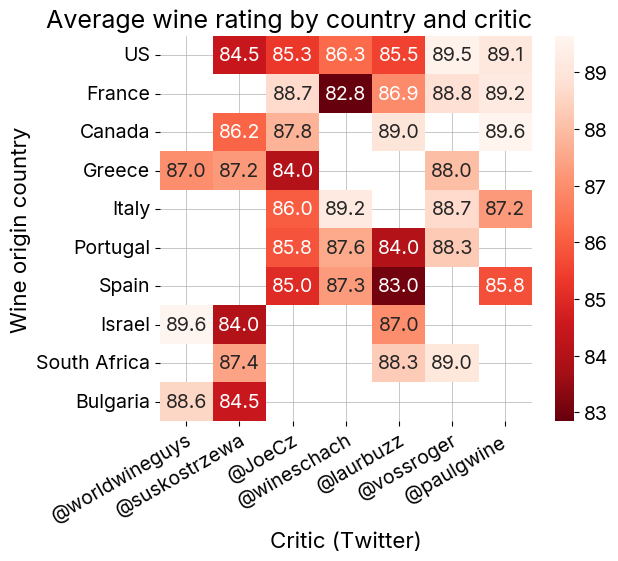

**Указание**: взяты не все страны и критики <font color='lightgray'>(были выбраны критики, которые оценивали наибольшее количество стран, а затем выбраны страны, вино из которых оценивали наибольшее число выбранных критиков, но можно просто выбрать страны и критиков так же, как на картинке)</font>

В ячейках указан средный рейтинг (`points`), выданный критиком винам из определенной страны.

In [295]:
top_crit = df.groupby('taster_twitter_handle')['country'].nunique().to_frame().sort_values('country', ascending = False)[:7].index
top_crit

Index(['@worldwineguys', '@suskostrzewa', '@JoeCz', '@wineschach',
       '@vossroger', '@laurbuzz', '@paulgwine '],
      dtype='object', name='taster_twitter_handle')

In [296]:
cntrs = df[df['taster_twitter_handle'].isin(top_crit)].groupby('country')['taster_twitter_handle'].nunique().to_frame().sort_values('taster_twitter_handle', ascending = False)[:10].index.to_list()
cntrs
# почему-то богария заменилась на венгрию :/


['US',
 'France',
 'Italy',
 'Greece',
 'Portugal',
 'Spain',
 'Canada',
 'Israel',
 'South Africa',
 'Hungary']

In [297]:
cntrs[-1] = 'Bulgary'
cntrs

['US',
 'France',
 'Italy',
 'Greece',
 'Portugal',
 'Spain',
 'Canada',
 'Israel',
 'South Africa',
 'Bulgary']

/tmp/ipython-input-2198609757.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  todraw = todraw.pivot_table(values='points', index='country', columns='taster_twitter_handle', aggfunc='first')


Text(1.0, 1.0, 'Average wine rating by country and critic')

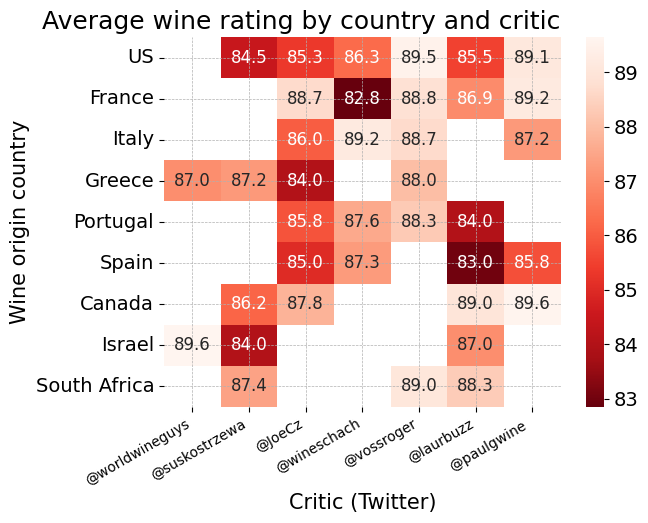

In [298]:
todraw = df[(df['country'].isin(cntrs)) & (df['taster_twitter_handle'].isin(top_crit))].groupby(['country', 'taster_twitter_handle']).points.mean().to_frame().reset_index()
# todraw.pivot(index=todraw.index, columns='taster_twitter_handle')['points']
todraw['country'] = pd.Categorical(todraw['country'], categories=cntrs)
todraw['taster_twitter_handle'] = pd.Categorical(todraw['taster_twitter_handle'], categories=top_crit)
todraw = todraw.pivot_table(values='points', index='country', columns='taster_twitter_handle', aggfunc='first')
todraw.sort_index(axis = 0)

plt.grid(linewidth=0.5, linestyle='--')
sns.heatmap(todraw, annot=True, fmt=".1f", cmap = 'Reds_r', annot_kws={"fontsize":12})
plt.ylabel('Wine origin country', size = 15)
plt.xlabel('Critic (Twitter)', size = 15)
plt.xticks(rotation=30, ha = 'right')
plt.title('Average wine rating by country and critic', loc = 'right', size = 18)

In [299]:
# если честно я перепробовала все подряд, разметка всегда рисуется поверх графика(

## Блок 2. **Tool**: информация о колонках датафрейма (4 балла)

#### чтобы получить полный балл, нужно прикрепить ваш правильно работающий пример в отдельном окошке

### Несколько слов про tool-блоки в домашках

Классного датасаентиста помимо всего прочего отличает его "портфель" - набор готового кода на все случаи жизни,
    который он носит с собой где бы он ни работал и какую бы домашку не делал. Во время различных профессиональных занятий
    всегда хорошо сохранить функцию, которая помогла вам сейчас решить конкретную задачу себе "в папочку", чтобы столкнувшись
    с такой / похожей задачей дальше, иметь под рукой oneliner, который сделает все так, как вам хочется.
    
Время от времени в ваших домашках будут появляться tool-блоки, в которых мы будем просить вас написать что-нибудь, что вам
    пригодится в дальнейшем, а также закрепляет пройденный материал.
    Настоятельно рекомендуем завести себе хранилище, куда вы будете складывать функции из домашек,
    а также те, которые напишете сами и сочтете достойными.

В дальнейшем вы сможете импортировать ваши функции в любой проект, например, так:

```
import sys
sys.path.append('/*SOME_PATH*/my_code/my_utils')
from utils.plot import plot_denisty
```

<br/>
Скорее всего, со временем вы захотите дополнить / исправить / переделать под себя эти функции, и это правильно,
    однако в домашках нужно сделать ровно то, что написано в задании - ни больше, ни меньше. Все остальное - уже самостоятельно.
    Можно воспринимать функции из домашек как шаблоны, вдохновляющие вас на дальнейшее творчество.
    Чтобы вы в будущем могли разобраться, что происходит у вас в коде (а тем более - проверяющие), мы будем просить вас писать
    комментарии к вашему коду и докстринги (пример ниже). Это несложная и очень полезная привычка, которая не раз выручит вас.

Условия проверки tool-блоков:
- Если какая-то часть задания не реализована или вы сделали что-то запрещенное, вы получаете 0 баллов за задачу
- Если сделано все, что описано в задании и не сделано ничего запрещенного, есть docstring и комментарии к коду,
    вы получаете полный балл за задачу
- После получения полного балла, могут быть вычтены баллы за любого рода неадекватность. Размер штрафа субъективен
    и коррелирует с масштабом неадекватности - на что-то можно закрыть глаза, на что-то не получится.
- Вспомогательные принты и любые следы тестирования - неадекватность
- Неадекватностью может являться кривое выполнение пункта задания, однако если мы посчитаем пункт кривым,
    это не значит, что у вас 0 за задачу. Не сделать и сделать неправильно - разные вещи
- Некоторые советы и намеки на то, что считается адекватным для конкретной задачи, можно будет найти в задании :)

### Задача 2.1 (4 балла)

Напишите функцию `get_df_info`, которая будет выводить информацию о колонках входного датафрейма. Функция должна возвращать датафрейм следующего формата:

- индекс - все колонки входного датафрейма


- в колонках результирующего датафрейма содержится следующая информация (см. пример ниже):
    - тип данных
        - используйте `df.col.dtype.name`, это стабильнее, чем `df.col.dtype`
    - количество уникальных элементов
        - включая наны
    - доля нанов в колонке
    - доля нулей в колонке
    - доля пустых строк в колонке
    - доля самого частовстречаемого элемента в колонке + сам этот элемент (aka `vc_max`)
        - исключая наны
        - в одной колонке или в двух разных - решать вам
        - если таких несколько - можно брать любой
        
    - два разных примера содержимого колонки
        - исключая наны
        - в одной колонке или в двух разных - решать вам
        
    - `trash_score` колонки: max([суммарная доля нанов, нулей и пустых строк], [`vc_max`.доля if `vc_max`.доля > thr else 0])
        - thr нужно принимать в качестве аргумента функции, поставив по умолчанию что-то адекватное
      
      
- про адекватность
    - нужно сделать так, чтобы как можно больше выводимой вами информации было понятно глазу без доп. усилий
    - округляйте до трех знаков доли
    - выводите чистый 0 спецсимволом, чтобы не путать с округлившимся 0.00001 (напр. '' или -1)
    - если нужно, выводите числа в виде строк
    - убедитесь, что в случае когда двух примеров не набирается, вы можете отличить информацию "примера нет" от пустой строки
    - можете использовать доп. символы, чтобы отличать колонки быстрее, где нужно (напр. 'z:', 'n:', 'e:')
    - обрабатывайте любые другие возникающие неадекватные ситуации и приводите их в адекватный вид :)
    
    
- запрещено: итерироваться по строкам входного датафрейма в любом виде (по колонкам можно)

Предлагается реализовать функцию на датасете Titanic, немного измененном следующим образом:

In [300]:
!wget https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/titanic_train.csv -O titanic_train.csv

--2025-10-02 19:39:50--  https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/titanic_train.csv
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61194 (60K) [text/csv]
Saving to: ‘titanic_train.csv’

titanic_train.csv   100%[===================>]  59.76K   386KB/s    in 0.2s    

2025-10-02 19:39:51 (386 KB/s) - ‘titanic_train.csv’ saved [61194/61194]



In [301]:
import pandas as pd

df = pd.read_csv('titanic_train.csv')
df['Embarked'] = df['Embarked'].replace('Q', '')
df['PassengerId'] = df['PassengerId'].astype('string')

In [302]:
# пусть код будет не супер продвинутым, но таким, чтобы через N времени он был таким же понятным (с кучей переменных с норм названиями и расписанными шагами)

In [303]:
def get_df_info(df, thr = 0.01, *args, **kwargs):

    N = df.shape[0]

    return_df = pd.DataFrame(data = None)

    coldict = {}

    for col in df.columns:

        # column dtype
        coltype = df[col].dtype.name
        coldict['dtype'] = coltype

        if coltype in ['string', 'object']:

            # elements = 0
            zero_num = 0
            coldict['zeros'] = -1

            # empty strings
            empty_str_num = (df[col] == '').sum()
            if empty_str_num != 0:
                coldict['empty_str'] = f"e: {empty_str_num / N:.3f}"
            else:
                coldict['empty_str'] = -1

        else:

            # elements 0
            zero_num = (df[col] == 0).sum()
            if zero_num != 0:
                coldict['zeros'] = f"Z: {zero_num / N:.3f}"
            else:
                coldict['zeros'] = -1

            # empty strings
            empty_str_num = 0
            coldict['empty_str'] = -1

        nan_num = df[col].isna().sum()
        if nan_num != 0:
            coldict['nan'] = f"n: {nan_num / N:.3f}"
        else:
            coldict['nan'] = -1


        # nunique with nans
        coldict['nunique'] = df[col].nunique(dropna=False)

        #______let's get vc_max and examples withous NaNs and ''s______
        clear_col = df[col].dropna()

        if coltype in ['string', 'object']:
            nunique_no_nan = clear_col[clear_col != ''].nunique(dropna=True)
        else:
            nunique_no_nan = clear_col.nunique(dropna=True)

        # two examples of column data
        if nunique_no_nan >= 2:
            coldict['example1'], coldict['example2'] = df[col].dropna().unique()[:2]
        elif nunique_no_nan == 1:
            coldict['example1'], coldict['example2'] = df[col].dropna().unique()[0], -1
        else:
            coldict['example1'], coldict['example2'] = -1, -1

        # most common el
        topel = clear_col.value_counts().sort_values(ascending = False)
        topelval = topel.index[0]

        # most common freq
        topelfreq = topel.values[0] / N
        coldict['vc_max'] = (topelval, f'{topelfreq:.3f}')

        # trash-score
        trash_score = max((nan_num + zero_num + empty_str_num) / N, topelfreq if topelfreq > thr else 0)
        if trash_score != 0:
            coldict['trash_score'] = f"{trash_score:.3f}"
        else:
             coldict['trash_score'] = -1

        return_df = pd.concat([return_df, pd.DataFrame([coldict])])
    return_df.index = df.columns
    return return_df

In [304]:
# ваш пример
get_df_info(df)

,dtype,zeros,empty_str,nan,nunique,example1,example2,vc_max,trash_score
PassengerId,string,-1,-1,-1,891,1,2,"(875, 0.001)",-1
Survived,int64,Z: 0.616,-1,-1,2,0,1,"(0, 0.616)",0.616
Pclass,int64,-1,-1,-1,3,3,1,"(3, 0.551)",0.551
Name,object,-1,-1,-1,891,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","(Bonnell, Miss. Elizabeth, 0.001)",-1
Sex,object,-1,-1,-1,2,male,female,"(male, 0.648)",0.648
Age,float64,-1,-1,n: 0.199,89,22.0,38.0,"(24.0, 0.034)",0.199
SibSp,int64,Z: 0.682,-1,-1,7,1,0,"(0, 0.682)",0.682
Parch,int64,Z: 0.761,-1,-1,7,0,1,"(0, 0.761)",0.761
Ticket,object,-1,-1,-1,681,A/5 21171,PC 17599,"(347082, 0.008)",-1
Fare,float64,Z: 0.017,-1,-1,248,7.25,71.2833,"(8.05, 0.048)",0.048


In [305]:
# Это пример, не запускайте эту ячейку

# WARNING: пример не обязан соблюдать все пункты задания, но вы обязаны :)

# get_df_info(df)

In [306]:
# о боже я случайно запустила, поэтому референсная таблица на фото ниже
# вообще, в некоторых ячейках мои ответы не сошлись с Вашими) причем ошибки по столбцу исходного df.

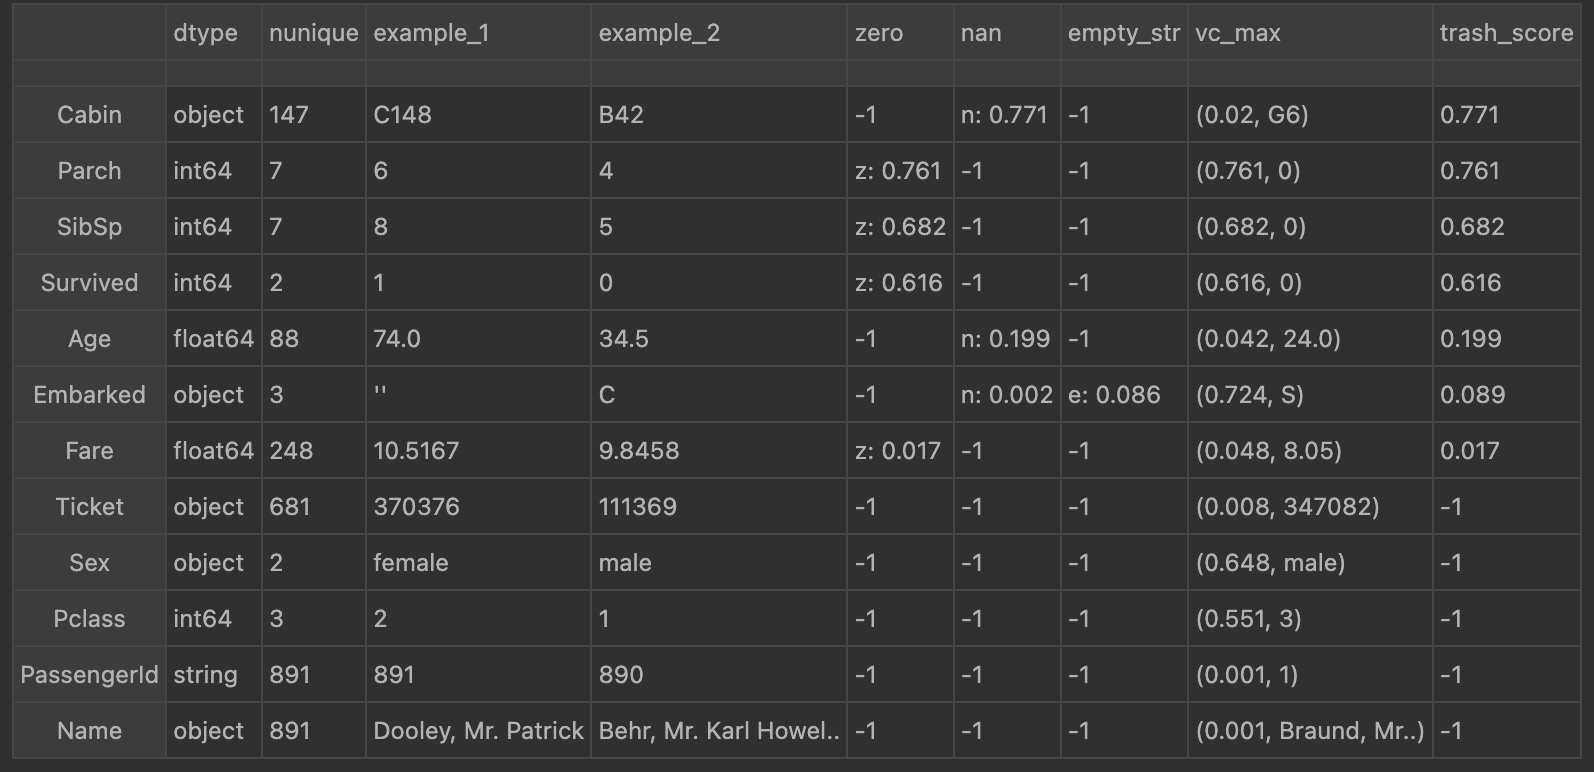

***Вопрос:*** Как вы думаете, какие проблемы с этой функцией могут возникнуть при применении ее на других датасетах?

 Во-первых, мне лично совсем не нравится колонка zero_counts. Мы считаем 0 в trash_score, но сам по себе 0 невинен и не означает плохой / пропущенный результат (например, бинарные переменные в виде интов, а не bool).

Во-вторых, если некоторые типы переменных работают +- одинаково (например, int и float или же string и object). Но существуют и другие форматы, которые работают по другому. Например, функция точно "сломается" на DateTime-формате (мы не можем сравнить DateTime с 0 и '', нужно прописать отдельное поведение для столбцов такого типа).

А еще датасет может быть составлен криво, NaN могут быть заменены на "?" итд. надо будет предобрабатывать по вызова функции